In [2]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
# df = pd.read_parquet("../../../data/Train/datos_holding_upsampled.parquet")
df = pd.read_parquet("../../../data/Train/datos_holding_with_runway.parquet")

df

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue,timestamp,tiempo_esperado,runway_occupied
0,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,149.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,Z3,True,18R/36L,2025-01-01,12,2025-01-01 11:58:47.210,0.0,1
1,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,144.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,Z3,True,18R/36L,2025-01-01,12,2025-01-01 11:58:52.210,5.0,1
2,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,139.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,Z3,True,18R/36L,2025-01-01,12,2025-01-01 11:58:57.210,10.0,1
3,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,134.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,Z3,True,18R/36L,2025-01-01,12,2025-01-01 11:59:02.210,15.0,1
4,aa5428,2025-01-01 11:58:47.210,2025-01-01 11:59:42.252,2025-01-01 12:01:16.916,129.706,Heavy (larger than 136000 kg),-3.572739,40.491817,-3.573822,40.491817,Z3,True,18R/36L,2025-01-01,12,2025-01-01 11:59:07.210,20.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606255,344195,2024-12-26 15:18:33.962,2024-12-26 15:20:16.160,2024-12-26 15:21:29.133,20.171,Medium 2 (between 34000 kg to 136000 kg),-3.576596,40.492463,-3.575500,40.492767,Z4,True,18R/36L,2024-12-26,15,2024-12-26 15:21:08.962,155.0,1
606256,344195,2024-12-26 15:18:33.962,2024-12-26 15:20:16.160,2024-12-26 15:21:29.133,15.171,Medium 2 (between 34000 kg to 136000 kg),-3.576596,40.492463,-3.575500,40.492767,Z4,True,18R/36L,2024-12-26,15,2024-12-26 15:21:13.962,160.0,1
606257,344195,2024-12-26 15:18:33.962,2024-12-26 15:20:16.160,2024-12-26 15:21:29.133,10.171,Medium 2 (between 34000 kg to 136000 kg),-3.576596,40.492463,-3.575500,40.492767,Z4,True,18R/36L,2024-12-26,15,2024-12-26 15:21:18.962,165.0,1
606258,344195,2024-12-26 15:18:33.962,2024-12-26 15:20:16.160,2024-12-26 15:21:29.133,5.171,Medium 2 (between 34000 kg to 136000 kg),-3.576596,40.492463,-3.575500,40.492767,Z4,True,18R/36L,2024-12-26,15,2024-12-26 15:21:23.962,170.0,1


(array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

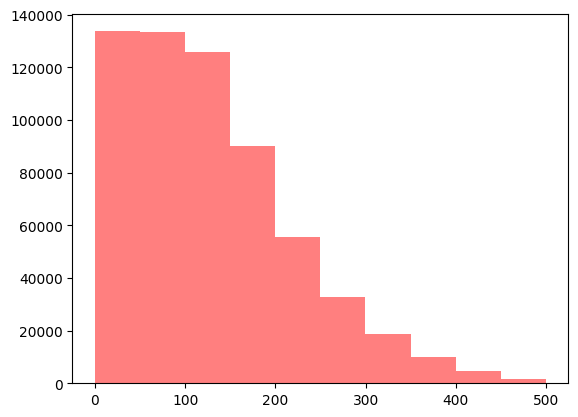

In [3]:
import matplotlib.pyplot as plt
plt.hist(df[df["parado"]==True]["tiempo_espera"], color="red", alpha=0.5, label="parado") 
plt.hist(df[df["parado"]==False]["tiempo_espera"], color="blue", alpha=0.5, label="no parado")

In [4]:
df.columns

Index(['ICAO', 'llegada_punto', 'salida_punto', 'despegue', 'tiempo_espera',
       'aircraft_type', 'llegada_lon', 'llegada_lat', 'salida_lon',
       'salida_lat', 'holding_point', 'parado', 'runway', 'fecha_despegue',
       'hora_despegue', 'timestamp', 'tiempo_esperado', 'runway_occupied'],
      dtype='object')

In [5]:
import pandas as pd
import numpy as np

def procesar_datos(df):
    df = df.copy()

    # --- Timestamps ---
    df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"], errors="coerce")

    # # Hora en segundos desde medianoche
    # df["segundos_llegada"] = df["timestamp"].dt.hour * 3600 + df["timestamp"].dt.minute * 60 + df["timestamp"].dt.second

    # Día de la semana (0=lunes, 6=domingo)
    df["dia_semana"] = df["fecha_despegue"].dt.weekday

    # Codificar si es fin de semana
    #df["es_finde"] = df["dia_semana"] >= 5

    # --- Categóricas como one-hot ---
    df = pd.get_dummies(df, columns=["aircraft_type", "holding_point"], drop_first=True)

    # --- Booleanas ---
    #df["parado"] = df["parado"].astype(int)
    #df["es_finde"] = df["es_finde"].astype(int)

    # --- Variables finales ---
    columnas_finales = ["tiempo_esperado", "dia_semana", "hora_despegue", "runway_occupied"] + \
                       [col for col in df.columns if col.startswith("aircraft_type_") or col.startswith("holding_point_")]

    x = df[columnas_finales].values.astype(np.float32)
    y = df["tiempo_espera"].values.astype(np.float32)

    umbral = 1000  # segundos
    mask = y < umbral

    x = x[mask]
    y = y[mask]

    mask = y > 0
    x = x[mask]
    y = y[mask]

    return x, y, columnas_finales

In [6]:
df = df[df["parado"]  == True]
x, y, columnas = procesar_datos(df)

In [7]:
columnas

['tiempo_esperado',
 'dia_semana',
 'hora_despegue',
 'runway_occupied',
 'aircraft_type_High vortex aircraft',
 'aircraft_type_Light (less than 7000 kg)',
 'aircraft_type_Medium 1 (between 7000 kg and 34000 kg)',
 'aircraft_type_Medium 2 (between 34000 kg to 136000 kg)',
 'holding_point_K2',
 'holding_point_K3',
 'holding_point_L1',
 'holding_point_LA',
 'holding_point_LB',
 'holding_point_LC',
 'holding_point_LD',
 'holding_point_LE',
 'holding_point_Y1',
 'holding_point_Y2',
 'holding_point_Y3',
 'holding_point_Z1',
 'holding_point_Z2',
 'holding_point_Z3',
 'holding_point_Z4']

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

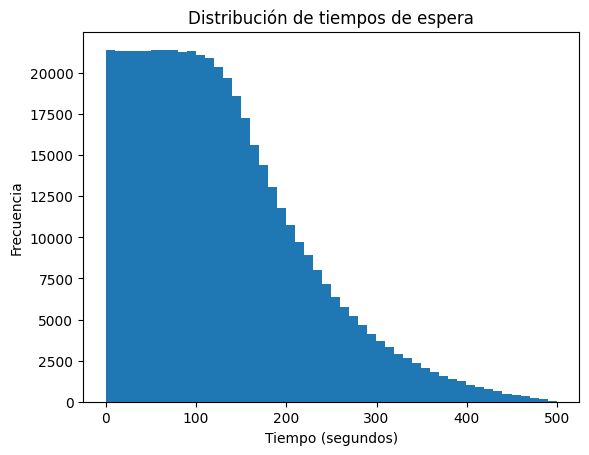

In [9]:
import matplotlib.pyplot as plt
plt.hist(y_train, bins=50)
plt.title("Distribución de tiempos de espera")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Frecuencia")
plt.show()

In [10]:
import numpyro
import numpyro.distributions as dist
import jax
import jax.numpy as jnp

def modelo_regresion(x, y=None):
    n_features = x.shape[1]

    # Priores para los coeficientes y bias
    beta = numpyro.sample("beta", dist.Normal(0, 1).expand([n_features]))
    intercept = numpyro.sample("intercept", dist.Normal(0, 5))
    sigma = numpyro.sample("sigma", dist.Exponential(1.0))  # escala del LogNormal

    # Predicción media (log del tiempo esperado)
    mu = intercept + jnp.dot(x, beta)

    # Tiempo de espera ~ LogNormal(mu, sigma)
    numpyro.sample("obs", dist.LogNormal(mu, sigma), obs=y)

In [11]:
from numpyro.infer import MCMC, NUTS

rng_key = jax.random.PRNGKey(0)
kernel = NUTS(modelo_regresion)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000)
mcmc.run(rng_key, x=x_train, y=y_train)
mcmc.print_summary()

sample: 100%|██████████| 2000/2000 [13:02:13<00:00, 23.47s/it, 127 steps of size 1.11e-03. acc. prob=0.90]       



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
    beta[0]     -0.01      0.00     -0.01     -0.01     -0.01   1104.08      1.00
    beta[1]      0.00      0.00      0.00      0.00      0.00   1534.06      1.00
    beta[2]      0.00      0.00      0.00      0.00      0.01   1086.21      1.00
    beta[3]     -0.26      0.00     -0.26     -0.26     -0.25   1142.11      1.00
    beta[4]     -0.28      0.03     -0.28     -0.33     -0.24    830.74      1.00
    beta[5]      0.19      0.02      0.19      0.16      0.21   1220.67      1.00
    beta[6]      0.04      0.01      0.04      0.03      0.05    866.06      1.00
    beta[7]     -0.08      0.00     -0.08     -0.08     -0.07   1170.87      1.00
    beta[8]     -0.34      0.01     -0.34     -0.36     -0.33    553.51      1.00
    beta[9]      0.14      0.05      0.14      0.06      0.24    164.64      1.00
   beta[10]      1.13      0.12      1.12      0.94      1.32    133.80      1.00
   beta[11]    

In [12]:
from numpyro.infer import Predictive

# Predictive posterior
predictive = Predictive(modelo_regresion, posterior_samples=mcmc.get_samples(), return_sites=["obs"])
preds = predictive(jax.random.PRNGKey(1), x=x_test)

# Media y percentiles
y_pred_mean = jnp.mean(preds["obs"], axis=0)
y_pred_lower = jnp.percentile(preds["obs"], 5, axis=0)
y_pred_upper = jnp.percentile(preds["obs"], 95, axis=0)

In [13]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_mean)
print("MAE:", mae)

# Opcional: imprimir algunos intervalos de confianza
for i in range(5):
    print(f"Ejemplo {i}: predicho {y_pred_mean[i]:.1f}s (95% CI: {y_pred_lower[i]:.1f} - {y_pred_upper[i]:.1f}), real: {y_test[i]:.1f}s")


MAE: 66.63973236083984
Ejemplo 0: predicho 99.6s (95% CI: 14.6 - 290.8), real: 64.0s
Ejemplo 1: predicho 85.0s (95% CI: 13.9 - 234.9), real: 95.5s
Ejemplo 2: predicho 379.8s (95% CI: 59.6 - 1195.3), real: 80.9s
Ejemplo 3: predicho 49.2s (95% CI: 7.8 - 146.7), real: 69.5s
Ejemplo 4: predicho 130.3s (95% CI: 19.3 - 375.7), real: 109.7s


In [14]:
# import jax.numpy as jnp
# import numpyro
# import numpyro.distributions as dist

# def modelo_aviones(x, punto_id, y_obs=None, num_puntos=5, num_pistas=3):
#     N, D = x.shape  # N datos, D variables

#     # Priori para probabilidades de pistas por punto de espera (categorical prior)
#     with numpyro.plate("puntos", num_puntos):
#         pi = numpyro.sample("pi", dist.Dirichlet(jnp.ones(num_pistas)))

#     # Intercepto por punto de espera
#     with numpyro.plate("alpha_puntos", num_puntos):
#         alpha = numpyro.sample("alpha", dist.Normal(0, 1))

#     # Efecto por pista (latente)
#     with numpyro.plate("pistas", num_pistas):
#         gamma = numpyro.sample("gamma", dist.Normal(0, 1))

#     # Coeficientes para covariables
#     beta = numpyro.sample("beta", dist.Normal(0, 1).expand([D]))

#     # Desviación estándar
#     sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))

#     with numpyro.plate("datos", N):
#         # Variable latente: pista asignada
#         z = numpyro.sample("z", dist.Categorical(probs=pi[punto_id]))

#         # Media para cada observación
#         mu = alpha[punto_id] + gamma[z] + jnp.sum(x * beta, axis=1)

#         # Modelo del tiempo de espera
#         numpyro.sample("obs", dist.LogNormal(mu, sigma), obs=y_obs)


In [15]:
# from numpyro.infer import MCMC, NUTS
# import jax.random as random

# # Supongamos que ya tienes: x, punto_id, y_obs
# # x: (N, D), punto_id: (N,), y_obs: (N,)
# rng_key = random.PRNGKey(0)

# kernel = NUTS(modelo_aviones)
# mcmc = MCMC(kernel, num_warmup=1000, num_samples=2000)
# mcmc.run(rng_key, x=x, punto_id=punto_id, y_obs=y_obs,
#          num_puntos=num_puntos, num_pistas=num_pistas)

# samples = mcmc.get_samples()

In [16]:
# import numpyro.infer

# # Ejemplo: para nuevos datos x_test y punto_id_test
# predictive = numpyro.infer.Predictive(
#     modelo_aviones, posterior_samples=samples, return_sites=["obs", "z"]
# )

# preds = predictive(rng_key, x=x_test, punto_id=punto_id_test,
#                    num_puntos=num_puntos, num_pistas=num_pistas)